# Timing-Dependent Learning Dynamics

## Motivation

Previous notebooks introduced spike-timing dependent plasticity (STDP) as a timing-sensitive learning rule. However, repeated application of unconstrained plasticity rules can produce unstable or biologically unrealistic weight dynamics.

This notebook examines how learning trajectories depend on weight bounds and parameter choices, and why additional regulation is often necessary in plasticity models.

## From Single Pairings to Learning Dynamics

In earlier examples, repeated spike pairings gradually changed synaptic weight. Here we focus more explicitly on how repeated updates accumulate over time and how parameter choices shape long-term behavior.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
A_plus = 0.01
A_minus = 0.012
tau_plus = 20.0
tau_minus = 20.0


def stdp_update(delta_t, A_plus=0.01, A_minus=0.012, tau_plus=20.0, tau_minus=20.0):
    """
    Compute a simplified STDP weight update from spike timing difference.
    """
    delta_t_array = np.asarray(delta_t)
    delta_w = np.zeros_like(delta_t_array, dtype=float)

    ltp_mask = delta_t_array > 0
    ltd_mask = delta_t_array < 0

    delta_w[ltp_mask] = A_plus * np.exp(-delta_t_array[ltp_mask] / tau_plus)
    delta_w[ltd_mask] = -A_minus * np.exp(delta_t_array[ltd_mask] / tau_minus)

    if np.isscalar(delta_t):
        return float(delta_w)

    return delta_w

In [2]:
initial_weight = 0.5
n_pairings = 200
fixed_delta_t = 10.0

In [3]:
weights_unbounded = np.zeros(n_pairings + 1)
weights_unbounded[0] = initial_weight

for pairing in range(1, n_pairings + 1):
    delta_w = stdp_update(
        fixed_delta_t,
        A_plus=A_plus,
        A_minus=A_minus,
        tau_plus=tau_plus,
        tau_minus=tau_minus
    )

    weights_unbounded[pairing] = weights_unbounded[pairing - 1] + delta_w

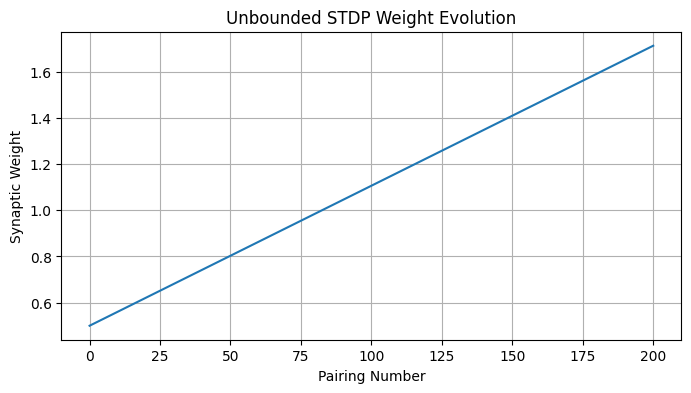

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(weights_unbounded)
plt.xlabel("Pairing Number")
plt.ylabel("Synaptic Weight")
plt.title("Unbounded STDP Weight Evolution")
plt.grid(True)
plt.show()

Without any regulatory mechanism, repeated potentiation can drive synaptic weights continuously upward. This behavior is useful for understanding the raw STDP rule, but it is biologically unrealistic if left unconstrained.

## Weight Bounds

One simple way to stabilize learning dynamics is to impose upper and lower bounds on synaptic weights.

This does not represent a complete biological homeostatic mechanism, but it prevents weights from diverging indefinitely.

In [5]:
w_min = 0.0
w_max = 1.0

weights_bounded = np.zeros(n_pairings + 1)
weights_bounded[0] = initial_weight

In [6]:
for pairing in range(1, n_pairings + 1):
    delta_w = stdp_update(
        fixed_delta_t,
        A_plus=A_plus,
        A_minus=A_minus,
        tau_plus=tau_plus,
        tau_minus=tau_minus
    )

    updated_weight = weights_bounded[pairing - 1] + delta_w

    # Apply weight bounds
    updated_weight = np.clip(updated_weight, w_min, w_max)

    weights_bounded[pairing] = updated_weight

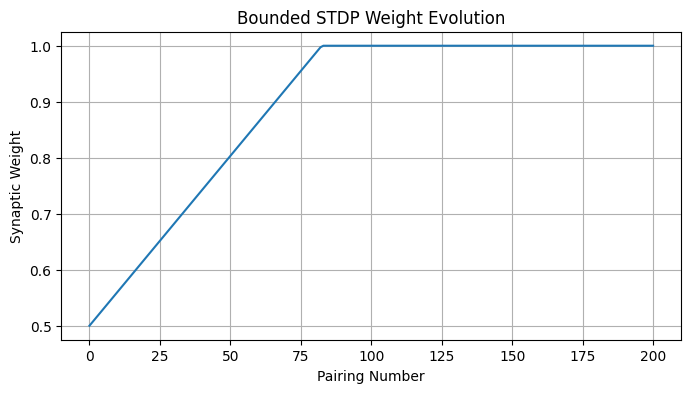

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(weights_bounded)
plt.xlabel("Pairing Number")
plt.ylabel("Synaptic Weight")
plt.title("Bounded STDP Weight Evolution")
plt.grid(True)
plt.show()

With weight bounds, the synaptic weight eventually saturates rather than growing indefinitely. This produces more stable long-term behavior.

## Comparing Bounded and Unbounded STDP

We can directly compare bounded and unbounded learning trajectories.

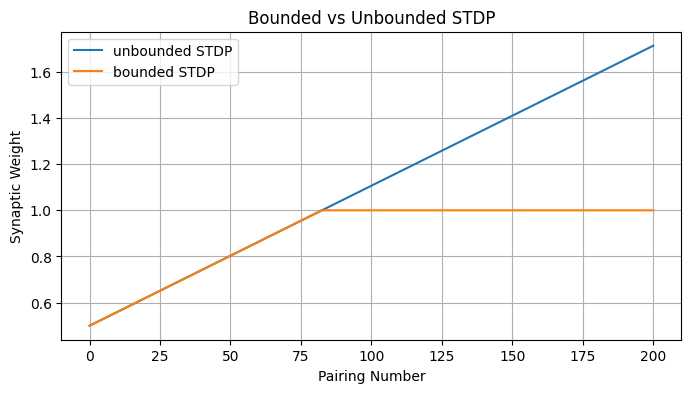

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(weights_unbounded, label="unbounded STDP")
plt.plot(weights_bounded, label="bounded STDP")
plt.xlabel("Pairing Number")
plt.ylabel("Synaptic Weight")
plt.title("Bounded vs Unbounded STDP")
plt.grid(True)
plt.legend()
plt.show()

This comparison highlights an important modeling issue: unconstrained plasticity rules can produce unstable learning dynamics. Weight normalization, homeostatic regulation, or modulatory control are often needed to stabilize learning.

## Parameter Sensitivity

Learning dynamics also depend strongly on parameter choices such as potentiation amplitude and timing constants.

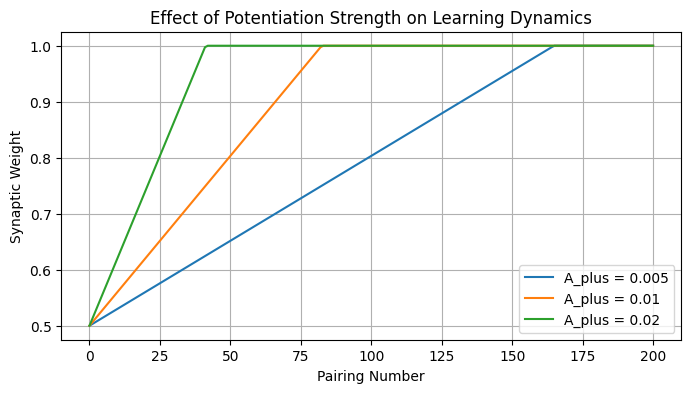

In [9]:
A_plus_values = [0.005, 0.01, 0.02]

plt.figure(figsize=(8, 4))

for A_plus_test in A_plus_values:
    weights_parameter = np.zeros(n_pairings + 1)
    weights_parameter[0] = initial_weight

    for pairing in range(1, n_pairings + 1):
        delta_w = stdp_update(
            fixed_delta_t,
            A_plus=A_plus_test,
            A_minus=A_minus,
            tau_plus=tau_plus,
            tau_minus=tau_minus
        )

        updated_weight = weights_parameter[pairing - 1] + delta_w
        updated_weight = np.clip(updated_weight, w_min, w_max)

        weights_parameter[pairing] = updated_weight

    plt.plot(weights_parameter, label=f"A_plus = {A_plus_test}")

plt.xlabel("Pairing Number")
plt.ylabel("Synaptic Weight")
plt.title("Effect of Potentiation Strength on Learning Dynamics")
plt.grid(True)
plt.legend()
plt.show()

Changing $A_+$ affects how quickly potentiation accumulates and how rapidly weights reach their upper bound. This sensitivity is important when interpreting plasticity simulations.

We can also examine the effect of the potentiation time constant $\tau_+$. A larger $\tau_+$ makes potentiation decay more slowly as the spike timing difference increases.

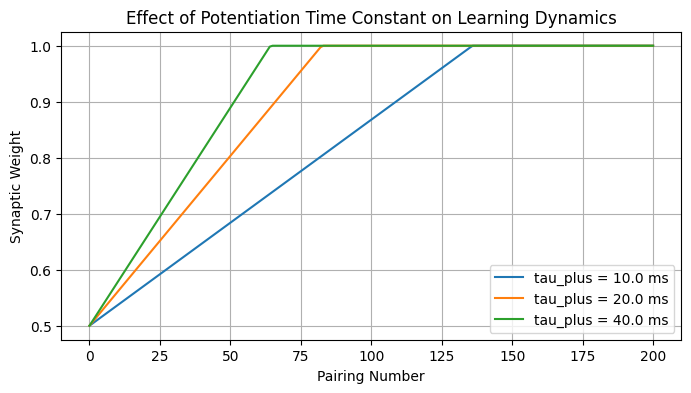

In [10]:
tau_plus_values = [10.0, 20.0, 40.0]

plt.figure(figsize=(8, 4))

for tau_plus_test in tau_plus_values:
    weights_tau = np.zeros(n_pairings + 1)
    weights_tau[0] = initial_weight

    for pairing in range(1, n_pairings + 1):
        delta_w = stdp_update(
            fixed_delta_t,
            A_plus=A_plus,
            A_minus=A_minus,
            tau_plus=tau_plus_test,
            tau_minus=tau_minus
        )

        updated_weight = weights_tau[pairing - 1] + delta_w
        updated_weight = np.clip(updated_weight, w_min, w_max)

        weights_tau[pairing] = updated_weight

    plt.plot(weights_tau, label=f"tau_plus = {tau_plus_test} ms")

plt.xlabel("Pairing Number")
plt.ylabel("Synaptic Weight")
plt.title("Effect of Potentiation Time Constant on Learning Dynamics")
plt.grid(True)
plt.legend()
plt.show()

This comparison shows that timing constants influence how strongly spike timing affects accumulated learning. Parameter choices therefore shape not only individual updates, but also the long-term trajectory of synaptic weights.

## Interpretation

These simulations illustrate that STDP is not only a local timing rule, but also a dynamical system whose long-term behavior depends on constraints, parameter choices, and repeated activity patterns.

Even simplified plasticity models can exhibit unstable growth, saturation, or highly timing-sensitive learning trajectories. Understanding these behaviors is important before moving to larger adaptive network models.

## Limitations

This notebook still uses a simplified phenomenological STDP rule rather than a detailed biological model of synaptic plasticity.

The model lacks realistic spike generation, recurrent connectivity, homeostatic feedback, inhibitory balance, neuromodulatory signals, and biophysical calcium dynamics. Weight clipping is used here as a simple stabilization method rather than a mechanistic biological process.

Therefore, these simulations should be interpreted as conceptual learning dynamics rather than realistic models of neural learning.

## Connection to Modulated Plasticity

In biological systems, synaptic plasticity is often influenced by additional modulatory mechanisms rather than operating in isolation.

The next step is to study how plasticity rules can be shaped by contextual signals, state-dependent modulation, or neuron–glia-inspired mechanisms that regulate when and how synaptic updates occur.
